# 06 Ensemble / stacking — dataset_3 (centrality + embeddings)

Combines the two approaches' threshold predictions per dataset. For each `p`: a **stacked** meta-learner
(LinearRegression on the two base predictions, trained on the **validation** split, evaluated on **test**)
and a simple **average** ensemble. Base predictions come from the per-dataset `*_threshold` notebooks.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for p in [start, *start.parents]:
        if (p / 'src').exists() and (p / 'requirements.txt').exists():
            return p
    raise FileNotFoundError('Project root not found.')

PROJECT_ROOT = find_project_root()
PRED = PROJECT_ROOT / 'src' / 'data' / 'predictions'
OUT  = PRED / 'dataset_3' / 'ensemble'; OUT.mkdir(parents=True, exist_ok=True)
TC = 'log_systemic_risk_label'
DATASETS = ['dataset_3']
P_LIST = ['p0', 'p5', 'p10', 'p15', 'p20', 'p25', 'p30', 'p35', 'p40']
rmse = lambda a, b: mean_squared_error(a, b) ** 0.5

## Build stacked + average ensembles per dataset / p

In [2]:
rows, all_preds = [], []
for ds in DATASETS:
    cen = pd.read_csv(PRED / ds / 'centrality_threshold' / 'predictions.csv')
    emb = pd.read_csv(PRED / ds / 'embedding_threshold' / 'predictions.csv')
    for p in P_LIST:
        c = cen[cen.p == p][['bank_id', 'split', TC, 'prediction']].rename(columns={'prediction': 'centrality_pred'})
        e = emb[emb.p == p][['bank_id', 'split', 'prediction']].rename(columns={'prediction': 'embedding_pred'})
        m = c.merge(e, on=['bank_id', 'split'], how='inner')
        val, test = m[m.split == 'validation'], m[m.split == 'test'].copy()
        stk = LinearRegression().fit(val[['centrality_pred', 'embedding_pred']], val[TC])
        test['average_pred'] = test[['centrality_pred', 'embedding_pred']].mean(axis=1)
        test['stacked_pred'] = stk.predict(test[['centrality_pred', 'embedding_pred']])
        y = test[TC]
        rows.append({'dataset': ds, 'p': p,
                     'centrality_rmse': rmse(y, test.centrality_pred),
                     'embedding_rmse':  rmse(y, test.embedding_pred),
                     'average_rmse':    rmse(y, test.average_pred),
                     'stacked_rmse':    rmse(y, test.stacked_pred),
                     'stacked_mae':     mean_absolute_error(y, test.stacked_pred)})
        test['dataset'] = ds; test['p'] = p; all_preds.append(test)

metrics = pd.DataFrame(rows)
metrics.to_csv(OUT / 'metrics.csv', index=False)
pd.concat(all_preds, ignore_index=True).to_csv(OUT / 'predictions.csv', index=False)
print('saved ->', OUT)
display(metrics.round(3))

saved -> /Users/rubenmarques/Documents/Repositórios/Thesis/src/data/predictions/dataset_3/ensemble


,dataset,p,centrality_rmse,embedding_rmse,average_rmse,stacked_rmse,stacked_mae
0,dataset_3,p0,0.329,0.694,0.435,0.327,0.167
1,dataset_3,p5,0.294,0.723,0.424,0.290,0.149
2,dataset_3,p10,0.294,0.723,0.424,0.290,0.149
3,dataset_3,p15,0.294,0.723,0.424,0.290,0.149
4,dataset_3,p20,0.325,0.736,0.446,0.317,0.153
5,dataset_3,p25,0.325,0.736,0.446,0.317,0.153
6,dataset_3,p30,0.325,0.736,0.446,0.317,0.153
7,dataset_3,p35,0.325,0.736,0.446,0.317,0.153
8,dataset_3,p40,0.325,0.736,0.446,0.317,0.153


## Plot: test RMSE across thresholds (per approach)

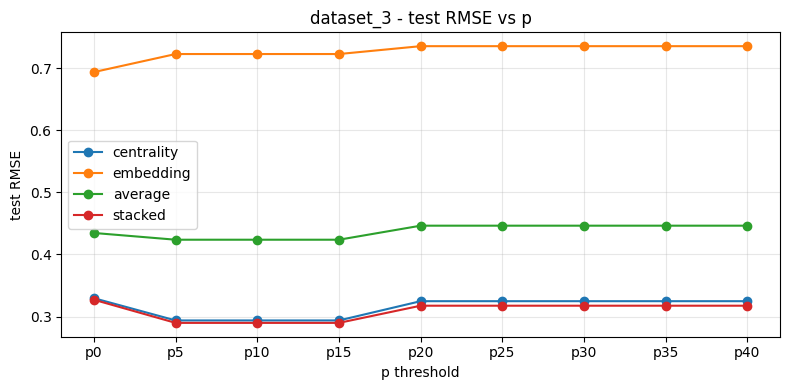

In [3]:
for ds in DATASETS:
    d = metrics[metrics.dataset == ds].set_index('p').loc[P_LIST]
    plt.figure(figsize=(8, 4))
    for col, lab in [('centrality_rmse','centrality'),('embedding_rmse','embedding'),('average_rmse','average'),('stacked_rmse','stacked')]:
        plt.plot(d.index, d[col], 'o-', label=lab)
    plt.title(f'{ds} - test RMSE vs p'); plt.xlabel('p threshold'); plt.ylabel('test RMSE'); plt.legend(); plt.grid(alpha=0.3)
    plt.tight_layout(); plt.savefig(OUT / f'{ds}_ensemble_rmse.png', dpi=90); plt.show()